# Convolution Neural Network:

## Importing the libraries

In [1]:
import tensorflow as tf
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [2]:
tf.__version__

'2.21.0'

## Part 1: Data Preprocessing

### Preprocessing the Training set

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip =True
)

training_set = train_datagen.flow_from_directory(
    'dataset/training_set',
    target_size=(64, 64),
    batch_size= 32,
    class_mode='binary'
)

Found 8000 images belonging to 2 classes.


### Preprocessing the test set

In [4]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(
    'dataset/test_set',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.


## Part 2: Building CNN

### Initialising CNN

In [5]:
cnn = tf.keras.models.Sequential()

### Step 1: Convolution

In [6]:
from warnings import filters
cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=[64, 64, 3]
    )
)


C:\Users\HP\anaconda3\envs\iManage\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 2: Pooling

In [7]:
cnn.add(tf.keras.layers.MaxPool2D(
    pool_size=2,
    strides=2
  )
)

#### Adding a second convolutional layer

In [8]:
cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu'
  )
)
cnn.add(tf.keras.layers.MaxPool2D(
    pool_size=2,
    strides=2
  )
)

### Step 3: Flattening

In [9]:
cnn.add(tf.keras.layers.Flatten())

### Step 4: Full Connection

In [10]:
cnn.add(tf.keras.layers.Dense(
    units=128,
    activation='relu'
  )
)

### Step 5: Output Layer

In [11]:
cnn.add(tf.keras.layers.Dense(
    units=1,
    activation='sigmoid'
  )
)

## Part 3: Training CNN

#### Compiling CNN

In [13]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Training CNN on Training set and evaluating it on Test set

In [14]:
cnn.fit(x = training_set, validation_data=test_set, epochs=25)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 303ms/step - accuracy: 0.5826 - loss: 0.6728 - val_accuracy: 0.6775 - val_loss: 0.6101
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.6786 - loss: 0.5964 - val_accuracy: 0.7350 - val_loss: 0.5401
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.7191 - loss: 0.5518 - val_accuracy: 0.7180 - val_loss: 0.5491
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.7401 - loss: 0.5203 - val_accuracy: 0.7510 - val_loss: 0.5066
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.7665 - loss: 0.4909 - val_accuracy: 0.7745 - val_loss: 0.4878
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.7697 - loss: 0.4839 - val_accuracy: 0.7420 - val_loss: 0.5273
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.7797 - loss: 0.4677 - val_accuracy: 0.7710 - val_loss: 0.4979
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.7937 - loss: 0.4409 -

## Part 4: Making a single prediction

In [17]:
import numpy as np
from keras.preprocessing import image

test_image = image.load_img('dataset/single_prediction/cat_or_dog_2.jpg', target_size = (64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)

result = cnn.predict(test_image)
training_set.class_indices

if result[0][0] == 1:
  prediction = 'dog'
else:
  prediction = 'cat'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [18]:
print(prediction)

cat


# Feature Extraction (for Similar Image Search)

In [52]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input
import numpy as np

## Feature extraction class

In [53]:
class FeatureExtractor:
    def __init__(self):
        # 1. Fixed spelling: 'imagenet'
        base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
        self.model = Model(inputs=base_model.input, outputs=base_model.output)

    def extract(self, img_path):
        try:
            # 2. Fixed target_size: MobileNetV2 usually expects (224, 224), not 244
            img = image.load_img(img_path, target_size=(224, 224))
            
            # 3. Fixed method name: 'img_to_array', not 'im_to_array'
            img_array = image.img_to_array(img)
            
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            features = self.model.predict(img_array)
            return features.flatten()
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return None

### Testing: Feature extraction class

In [54]:
fe = FeatureExtractor()

test_image = "dataset/single_prediction/cat_or_dog_2.jpg"
features = fe.extract(test_image)

print("Feature vector length: ", len(features))

C:\Users\HP\AppData\Local\Temp\ipykernel_3800\2964257629.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
Feature vector length:  1280


### Extract Features for all images in similarity_images

In [55]:
import os

dataset_path = "dataset/similarity_dataset"

image_paths = []
features_list = []

for file in os.listdir(dataset_path):
    img_path = os.path.join(dataset_path, file)

    features = fe.extract(img_path)

    if features is not None:
        image_paths.append(img_path)
        features_list.append(features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [56]:
print("Total images processed: ", len(features_list))

Total images processed:  47


## Convert to Numpy array

In [57]:
features_array = np.array(features_list)
print(features_array.shape)

(47, 1280)


## Build Similarity Search

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_images(query_img, top_k=5):
    query_features = fe.extract(query_img)

    similarities = cosine_similarity([query_features], features_array)[0]

    indices = np.argsort(similarities)[::-1][:top_k]

    results = [(image_paths[i], similarities[i]) for i in indices]

    return results

## Test Search

In [59]:
query_image = "dataset/single_prediction/cat_or_dog_2.jpg"

results = find_similar_images(query_image)

for img, score in results:
    print(img, " | similarity: ", score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
dataset/similarity_dataset\cat.0.jpg  | similarity:  0.9999998
dataset/similarity_dataset\cat.7.jpg  | similarity:  0.73707306
dataset/similarity_dataset\cat.10.jpg  | similarity:  0.7100184
dataset/similarity_dataset\cat.21.jpg  | similarity:  0.70540786
dataset/similarity_dataset\cat.3.jpg  | similarity:  0.7053367


## Visualization imports

In [62]:
import matplotlib.pyplot as plt
from PIL import Image

In [67]:
def show_results(query_img, results):
    plt.figure(figsize=(15, 5))

    # Show query image
    plt.subplot(1, len(results) +1, 1)
    img = Image.open(query_img)
    plt.imshow(img)
    plt.title("Query")
    plt.axis("off")

    # Show similar images
    for i, (img_path, score) in enumerate(results):
        plt.subplot(1, len(results) + 1, i + 2)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"{score:.2f}")
        plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


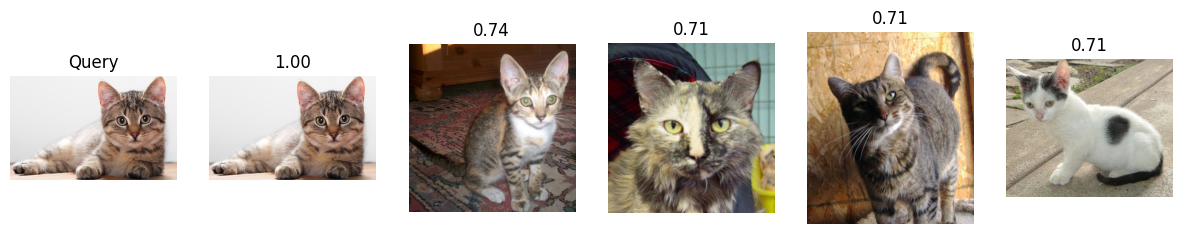

In [68]:
query_image = "dataset/single_prediction/cat_or_dog_2.jpg"

results = find_similar_images(query_image)

show_results(query_image, results)